In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [ ]:
def jacobi_preconditioned_conjugate_gradient(A: np.ndarray, b: np.ndarray, x0: np.ndarray = None, tol: float = 1e-10, max_iter: int = 1000) -> np.ndarray:
    """
    Solve the linear system Ax = b using the Jacobi Preconditioned Conjugate Gradient method.
    Parameters:
    A : np.ndarray
        Symmetric positive-definite matrix.
    b : np.ndarray
        Right-hand side vector.
    x0 : np.ndarray, optional
        Initial guess for the solution (default is a zero vector).
    tol : float, optional
        Tolerance for convergence (default is 1e-10).
    max_iter : int, optional
        Maximum number of iterations (default is 1000).
    """

    # number of rows
    n = A.shape[0]

    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()

    r = b - A @ x
    M_inv = 1 / np.diag(A)  # Jacobi preconditioner (inverse of diagonal elements)
    z = M_inv * r
    p = z.copy()
    rs_old = np.dot(r, z)

    for i in range(max_iter):
        Ap = A @ p
        alpha = rs_old / np.dot(p, Ap)

        x = x + alpha * p
        r = r - alpha * Ap
        
        z = M_inv * r
        rs_new = np.dot(r, z)
        if np.sqrt(rs_new) / np.sqrt(rs_old) < tol:
            print("Converged")
            break

        beta = rs_new / rs_old

        p = z + beta * p

        rs_old = rs_new

    return x   

# Example usage
if __name__ == "__main__":
    # Define a symmetric positive-definite matrix A and vector b
    A = np.array([[4, 1], [1, 3]], dtype=float)
    b = np.array([1, 2], dtype=float)

    # Solve for x in Ax = b
    import time
    start_time = time.time()
    x = jacobi_preconditioned_conjugate_gradient(A, b)
    end_time = time.time()
    print("Time taken:", (end_time - start_time) / 60, "minutes")
    assert np.allclose(x, np.array([0.090909, 0.636364]))
    print("Solution x:", x)

In [ ]:
def check_spd_properties(A: np.ndarray) -> None:
    print(f"Matrix shape: {A.shape}")
    print(f"Matrix:\n{A}\n")

    # Check symmetry
    is_sym = np.allclose(A, A.T, atol=1e-10)
    print(f"✓ Symmetric: {is_sym}")

    # Check SPD via eigenvalues
    eigvals = np.linalg.eigvalsh(A)
    print(f"Eigenvalues: {eigvals}")
    is_spd = np.all(eigvals > 1e-10)
    print(f"✓ Positive definite (all eigenvalues > 0): {is_spd}")

    # Condition number
    if is_spd:
        cond_num = np.max(eigvals) / np.min(eigvals)
        print(f"Condition number: {cond_num:.2e}")

    # Check diagonal dominance
    diag = np.diag(A)
    row_sums = np.sum(np.abs(A), axis=1) - np.abs(diag)
    is_dd = np.all(np.abs(diag) > row_sums)
    print(f"✓ Diagonally dominant: {is_dd}")

    # Check 27-point stencil structure (for 3D Laplacian on a grid)
    n = A.shape[0]
    grid_size = round(n ** (1/3))
    
    if grid_size ** 3 == n:
        print(f"\n✓ Matrix size {n} = {grid_size}³ (consistent with 3D grid)")
        
        # Check typical 27-point stencil pattern for interior points
        # For a 3D Laplacian with 27-point stencil, each interior point connects to 27 neighbors
        max_nnz_per_row = 27
        nnz_per_row = np.count_nonzero(A, axis=1)
        
        # Count rows with different numbers of non-zeros
        boundary_rows = np.sum(nnz_per_row < max_nnz_per_row)
        interior_rows = np.sum(nnz_per_row == max_nnz_per_row)
        
        print(f"  - Interior points (27 non-zeros): {interior_rows}")
        print(f"  - Boundary points (<27 non-zeros): {boundary_rows}")
        print(f"  - Average non-zeros per row: {np.mean(nnz_per_row):.1f}")
        
        # Check if diagonal is dominant (expected for 27-point stencil)
        center_weight = np.abs(diag[0])
        print(f"  - Typical center coefficient: {center_weight:.2e}")
    else:
        print(f"\n✗ Matrix size {n} does not match a cubic grid (nearest: {grid_size}³ = {grid_size**3})")


In [9]:
def load_matrix_from_binary_check_spd(file_path: str) -> None:
    """Load a square matrix from a binary file with the specified format.
       the function to check the dense matrix properties: symmetric, SPD, condition number, diagonal dominance.
    """
    with open("../data/matrix.bin", "rb") as f:
        n_rows = np.fromfile(f, dtype=np.int32, count=1)[0]
        n_cols = np.fromfile(f, dtype=np.int32, count=1)[0]
        assert n_rows == n_cols, f"Not square: {n_rows}x{n_cols}"
        A = np.fromfile(f, dtype=np.float64, count=n_rows * n_cols).reshape(n_rows, n_cols)

    check_spd_properties(A)

In [ ]:
DATA_PATH = "../output/"

matrix_bin_path = DATA_PATH + "matrix_dense.bin"
matrix_mtx_path = DATA_PATH + "csr_matrix_full.mtx"

In [ ]:
# check the properties of the matrix loaded from the .bin file
load_matrix_from_binary_check_spd(matrix_bin_path)

In [ ]:
def load_matrix_from_mtx_and_check_spd(file_path: str) -> None:
    """Load a square matrix from a Matrix Market (.mtx) file int a compressed format."""
    from scipy.io import mmread
    A = mmread(file_path).toarray()
    n_rows, n_cols = A.shape
    assert n_rows == n_cols, f"Not square: {n_rows}x{n_cols}"
    
    check_spd_properties(A)

In [ ]:
# check the properties of the matrix loaded from the .mtx file
load_matrix_from_mtx_and_check_spd(matrix_mtx_path)

In [ ]:
def compute_speedups(serial_time: list, parallel_times: list) -> list:
    """
    Compute speedups given serial and parallel execution times.
    Parameters:
        serial_time : Execution time of the serial implementation.
        parallel_times : Execution times of the parallel implementations.
    Returns:
        List of speedup values.
    """
    return [serial_time / t for t in parallel_times]

def compute_efficiencies(speedups: list, num_processors: list) -> list:
    """
    Compute efficiencies given speedups and number of processors.
    Parameters:
        speedups : List of speedup values.
        num_processors : List of number of processors used.
    Returns:
        List of efficiency values.
    """
    return [s / p for s, p in zip(speedups, num_processors)]

In [ ]:
def read_file_to_csv(file_path: str = "../output/jcgtimes.txt") -> pd.DataFrame:
    """Read the jcgtimes.txt file into a pandas DataFrame."""
    times = pd.read_csv(file_path, sep=r'\s+')
    times_final = times.groupby(by=['#grid_size', 'num_processes'], as_index=False).agg({
        'max_time_seconds': 'mean',
        'min_time_seconds': 'mean',
    }).rename(columns={
        'max_time_seconds': 'avg_max_time_seconds',
        'min_time_seconds': 'avg_min_time_seconds'
    })
    return times_final

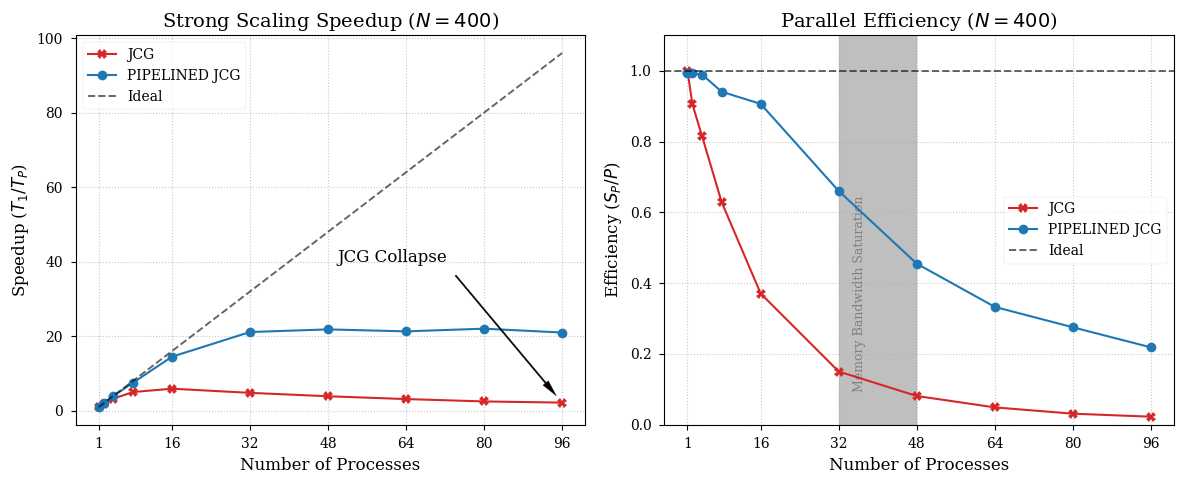

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use a professional style
plt.style.use('seaborn-v0_8-paper') # or 'bmh' if seaborn is not installed
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "savefig.dpi": 300
})

def plot_intra_node_strong_scaling(file_path="../output/jcgtimes_intra_node.txt", grid_size=400):
    # Load and process data
    df = pd.read_csv(file_path)
    subset = df[df["grid_size"] == grid_size]
    
    # Minimum repetitions
    avg_df = subset.groupby(["algorithm", "num_processes"]).min().reset_index()
    
    # T1 Reference: Baseline at 1 rank
    t_serial = avg_df[(avg_df["algorithm"] == "baseline") & (avg_df["num_processes"] == 1)]["total_time_max"].values[0]

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    colors = {'baseline': '#d62728', 'pipelined': '#1f77b4'}
    markers = {'baseline': 'X', 'pipelined': 'o'}

    for alg in ['baseline', 'pipelined']:
        alg_data = avg_df[avg_df["algorithm"] == alg].sort_values("num_processes")
        procs = alg_data["num_processes"].values
        times = alg_data["total_time_max"].values
        
        speedup = t_serial / times
        efficiency = speedup / procs
        
        # --- Ax1: Speedup ---
        ax1.plot(procs, speedup, color=colors[alg], marker=markers[alg], 
                 label=f'{'JCG' if alg == 'baseline' else 'Pipelined JCG'.upper()}', linewidth=1.5, markersize=7)
        
        # --- Ax2: Efficiency ---
        ax2.plot(procs, efficiency, color=colors[alg], marker=markers[alg], 
                 label=f'{'JCG' if alg == 'baseline' else 'Pipelined JCG'.upper()}', linewidth=1.5, markersize=7)

    # --- Formatting Speedup (Ax1) ---
    max_p = avg_df["num_processes"].max()
    ax1.plot([1, max_p], [1, max_p], 'k--', alpha=0.6, label='Ideal')
    ax1.set_title(f'Strong Scaling Speedup ($N={grid_size}$)')
    ax1.set_xlabel('Number of Processes')
    ax1.set_ylabel('Speedup ($T_1 / T_P$)')
    ax1.set_xticks([1, 16, 32, 48, 64, 80, 96])
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()

    # --- Formatting Efficiency (Ax2) ---
    ax2.axhline(y=1.0, color='k', linestyle='--', alpha=0.6, label='Ideal')
    ax2.set_title(f'Parallel Efficiency ($N={grid_size}$)')
    ax2.set_xlabel('Number of Processes')
    ax2.set_ylabel('Efficiency ($S_P / P$)')
    ax2.set_xticks([1, 16, 32, 48, 64, 80, 96])
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend()

    # --- Annotations for Analysis ---
    # Annotate the baseline collapse
    ax1.annotate('JCG Collapse', xy=(96, t_serial/avg_df[(avg_df["algorithm"] == "baseline") & (avg_df["num_processes"] == 96)]["total_time_max"].values[0]), 
                 xytext=(50, 40), arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    # Annotate the memory wall area
    ax2.axvspan(32, 48, color='gray', alpha=0.5, zorder=0)
    ax2.text(35, 0.1, 'Memory Bandwidth Saturation', rotation=90, color='gray', fontsize=9, zorder=1)

    plt.tight_layout()
    plt.savefig(f"../plots/strong_scaling_results_grid{grid_size}.pdf")
    plt.show()

# Run the plotter
plot_intra_node_strong_scaling()

Grid 512, Alg baseline, Speeds: [1.         1.02544069 0.92038896]
Grid 512, Alg pipelined, Speeds: [13.41098823 23.1770492  33.65109787]
Grid 875, Alg baseline, Speeds: [1.         1.09436363 1.13702906]
Grid 875, Alg pipelined, Speeds: [13.07104777 23.35193747 37.48955346]


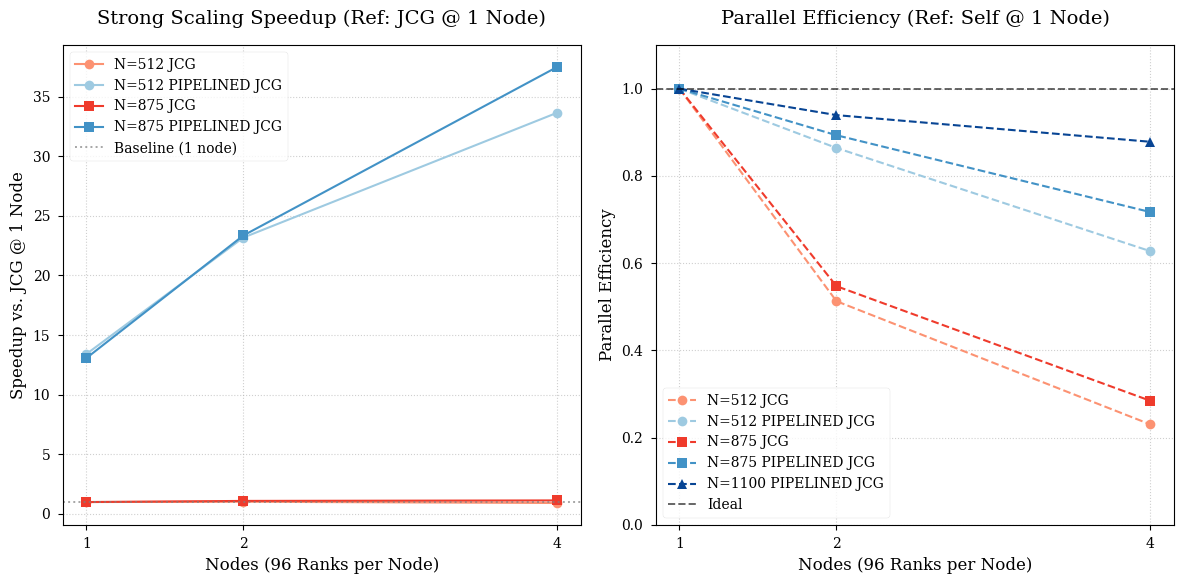

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-paper') # or 'bmh' if seaborn is not installed
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "savefig.dpi": 300
})

INTERNODE_MARKERS = {512: 'o', 875: 's', 1100: '^'}
ALGO_MARKERS = {'baseline': 'X', 'pipelined': 'o'}

REF_RANKS = 96  # 1 Node

INTERNODE_COLORS = {
    512:  {'pipelined': '#9ecae1', 'baseline': '#fc9272'}, # Light Blue / Light Red
    875:  {'pipelined': '#4292c6', 'baseline': '#ef3b2c'}, # Medium Blue / Medium Red
    1100: {'pipelined': '#084594', 'baseline': '#67000d'}  # Dark Blue / Dark Red
}

def combine_csv_files(file_paths):
    """Combines multiple CSV files into a single DataFrame."""
    dataframes = [pd.read_csv(p) for p in file_paths if isinstance(p, str)]
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

def plot_ghysels_TOTAL_projected_speedup(file_paths):
    """Calculates Speedup using per-grid baseline reference."""
    df = combine_csv_files(file_paths)
    
    df_clean = df.groupby(['algorithm', 'grid_size', 'num_processes']).min().reset_index()
    
    # Project fair total times
    iter_map = df_clean[df_clean['algorithm'] == 'pipelined'].groupby('grid_size')['total_iters'].max().to_dict()
    
    def projected_total_time(row):
        setup_time = row['total_time_max'] - row['iter_time_max']
        target_iters = iter_map.get(row['grid_size'], 0)
        
        if row['algorithm'] == 'pipelined' or row['total_iters'] >= target_iters - 2: # Allow small tolerance even though the difference should be 0 +-1
            return row['total_time_max']
        else:
            return setup_time + (target_iters * row['avg_iter_time'])

    df_clean['projected_total_time'] = df_clean.apply(projected_total_time, axis=1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    grids = sorted(df_clean['grid_size'].unique())
    
    for grid in grids:
        g_key = int(grid)
        
        #Get baseline reference FOR THIS SPECIFIC GRID
        ref_query = df_clean[(df_clean['algorithm'] == 'baseline') & 
                             (df_clean['num_processes'] == REF_RANKS) & 
                             (df_clean['grid_size'] == grid)]  # Match grid!
        
        if ref_query.empty:
            print(f"Warning: No baseline reference for grid {grid}")
            # continue
        else:
            ref_val = ref_query['projected_total_time'].values[0]
        
        for alg in ['baseline', 'pipelined']:
            subset = df_clean[(df_clean['grid_size'] == grid) & 
                              (df_clean['algorithm'] == alg)].sort_values('num_processes')
            
            if subset.empty: continue
            
            color = INTERNODE_COLORS.get(g_key, {}).get(alg, 'gray')
            marker = INTERNODE_MARKERS.get(g_key, 'x')
            label = f"N={g_key} {'JCG' if alg == 'baseline' else 'Pipelined JCG'.upper()}"

            if not ref_query.empty:
                # Speedup relative to THIS grid's baseline
                speedup = ref_val / subset['projected_total_time']    
                print(f"Grid {grid}, Alg {alg}, Speeds: {speedup.values}")

                # --- Plot Speedup ---
                ax1.plot(subset['num_processes'], speedup, 
                        marker=marker, color=color, label=label, linewidth=1.5, markersize=7)
                
            # Efficiency relative to THIS algorithm @ 1 Node for THIS grid
            ref_alg = df_clean[(df_clean['algorithm'] == alg) & 
                               (df_clean['num_processes'] == REF_RANKS) & 
                               (df_clean['grid_size'] == grid)]
            
            if ref_alg.empty:
                print(f"Warning: No reference for algorithm {alg} at grid {grid}")
                continue

            ref_alg_time = ref_alg['projected_total_time'].values[0]
            speedup_alg = ref_alg_time / subset['projected_total_time']        

            num_nodes = subset['num_processes'] / REF_RANKS
            efficiency = speedup_alg / num_nodes

            # print(f"Grid {grid}, Alg {alg}, Nodes: {num_nodes.values}, Efficiency: {efficiency.values}")
                    
            
        
            # --- Plot Efficiency ---
            ax2.plot(subset['num_processes'], efficiency, 
                     marker=marker, color=color, linestyle='--', label=label, linewidth=1.5, markersize=7)

    ax1.set_title('Strong Scaling Speedup (Ref: JCG @ 1 Node)', fontsize=14, pad=15)
    ax1.set_ylabel('Speedup vs. JCG @ 1 Node', fontsize=12)
    ax1.set_xlabel('Nodes (96 Ranks per Node)', fontsize=12)
    ax1.set_xticks([96, 192, 384], ['1', '2', '4'])
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.axhline(y=1.0, color='gray', linestyle=':', alpha=0.7, label='Baseline (1 node)')
    ax1.legend()
    
    # --- Format Efficiency (Right) ---
    ax2.axhline(y=1.0, color='k', linestyle='--', alpha=0.6, label='Ideal')
    ax2.set_title('Parallel Efficiency (Ref: Self @ 1 Node)', fontsize=14, pad=15)
    ax2.set_ylabel('Parallel Efficiency', fontsize=12)
    ax2.set_xlabel('Nodes (96 Ranks per Node)', fontsize=12)
    ax2.set_xticks([96, 192, 384], ['1', '2', '4'])
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig("../plots/internode_strong_scaling.pdf")
    plt.show()

files = ["../output/jcgtimes_512_strong_scaling.txt", 
         "../output/jcgtimes_875_1100.txt"]
plot_ghysels_TOTAL_projected_speedup(file_paths=files)

Grid 512, Alg baseline, Throughput: [0.31062711 0.31852003 0.28588492]
Grid 512, Alg pipelined, Throughput: [ 4.21606489  7.28613376 10.58201058]
Grid 875, Alg baseline, Throughput: [0.06796221 0.07437303 0.07727121]
Grid 875, Alg pipelined, Throughput: [0.89507966 1.59906103 2.56736773]
Grid 1100, Alg baseline, Throughput: [0.03024003]
Grid 1100, Alg pipelined, Throughput: [0.45516116 0.85526445 1.5998285 ]


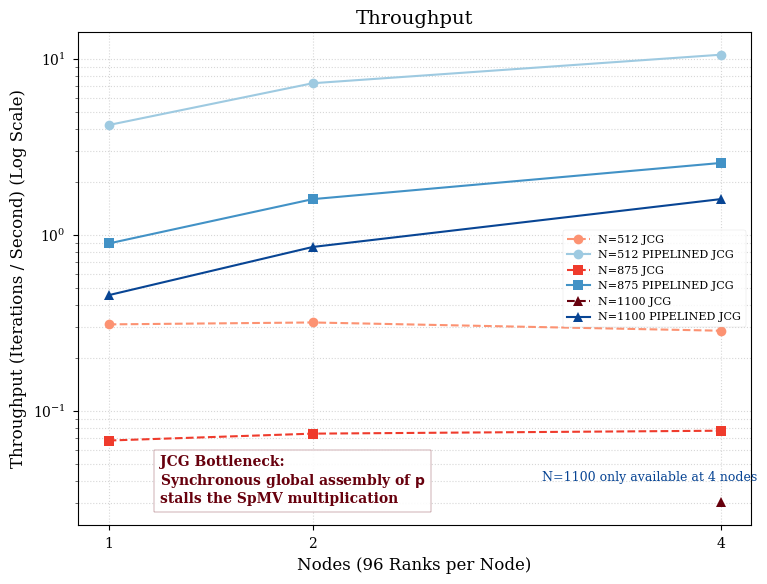

In [8]:
def plot_internode_throughput(df):
    """
    Plots TRUE Throughput (Iterations per Second).
    Higher is better.
    """
    plt.figure(figsize=(8, 6))
    grids = sorted(df['grid_size'].unique())
    
    for grid in grids:
        for alg in ['baseline', 'pipelined']:
            df = df.groupby(['algorithm', 'grid_size', 'num_processes']).min().reset_index()
            data = df[(df['grid_size'] == grid) & (df['algorithm'] == alg)].sort_values('num_processes')
            if data.empty: continue
            
            # CALCULATE THROUGHPUT: Iterations per Second
            throughput = 1.0 / data['avg_iter_time']
            print(f"Grid {grid}, Alg {alg}, Throughput: {throughput.values}")
            
            ls = '--' if alg == 'baseline' else '-'
            label = f"N={grid} {'JCG' if alg == 'baseline' else 'Pipelined JCG'.upper()}"
            
            plt.plot(data['num_processes'], throughput, 
                     color=INTERNODE_COLORS[grid][alg], 
                     marker=INTERNODE_MARKERS[grid], 
                     linestyle=ls, label=label, linewidth=1.5, markersize=7)

    plt.yscale('log') # Log scale is still best for showing the massive range
    plt.title('Throughput')
    plt.xlabel('Nodes (96 Ranks per Node)')
    plt.ylabel('Throughput (Iterations / Second) (Log Scale)')
    plt.xticks([96, 192, 384], ['1', '2', '4'])
    plt.grid(True, which="both", ls=":", alpha=0.5)
    
    # Place legend outside to the right
    plt.legend(fontsize=8)

    # Position this text based on your data (e.g., near the Baseline lines)
    plt.text(120, 0.03, 
         "JCG Bottleneck:\nSynchronous global assembly of $\\mathbf{p}$\nstalls the SpMV multiplication", 
         color='#67000d', fontsize=10, fontweight='bold', 
         bbox=dict(facecolor='white', edgecolor='#67000d', alpha=0.9))
    
    # After plotting, add:
    plt.text(300, 0.04, "N=1100 only available at 4 nodes", color='#084594', fontsize=9)

    plt.tight_layout()
    plt.savefig("../plots/internode_throughput_rate.pdf")
    plt.show()
combined_df = combine_csv_files(files)
plot_internode_throughput(combined_df)

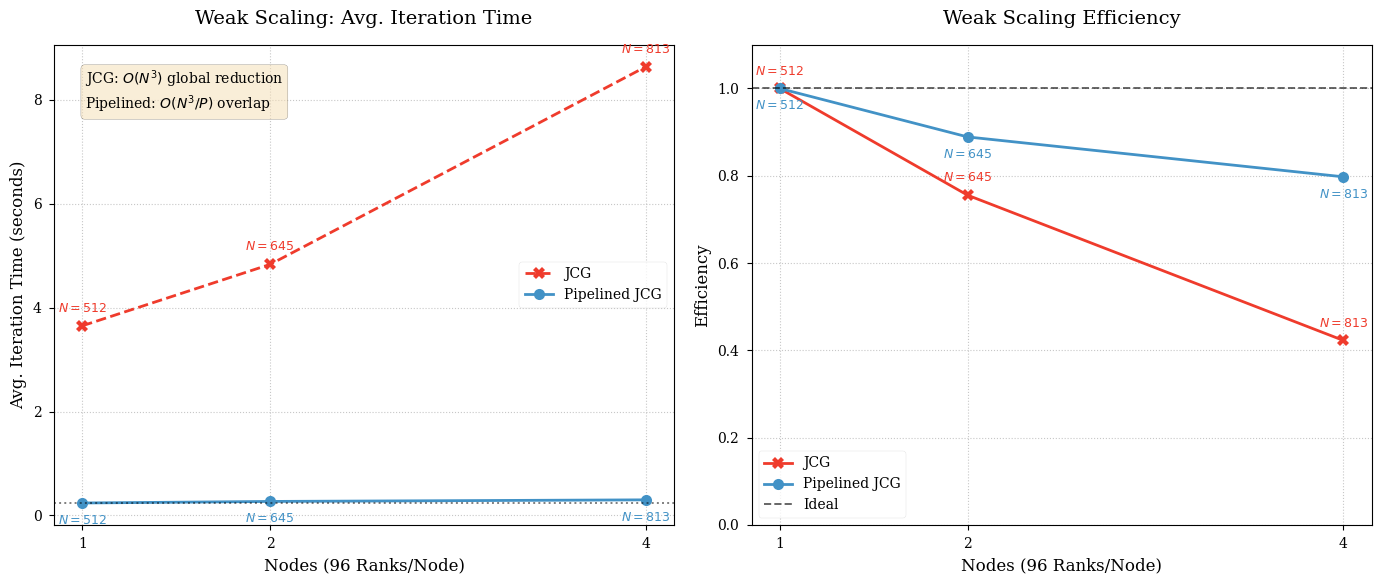

,algorithm,grid_size,num_processes,total_time_max,total_time_min,iter_time_max,iter_time_min,total_iters,avg_iter_time
0,baseline,512,96,752.598818,752.598386,752.062609,752.062561,206,3.650789
1,pipelined,512,96,49.636564,49.636259,49.281146,49.281110,207,0.238073
2,baseline,512,96,663.219931,663.219625,663.174647,663.174423,206,3.219294
3,pipelined,512,96,49.453472,49.453177,49.097813,49.097776,207,0.237188
4,baseline,512,96,670.375722,670.375272,670.330450,670.330209,206,3.254031
5,pipelined,512,96,49.502012,49.501645,49.144220,49.144181,207,0.237412
18,pipelined,645,192,55.861211,55.846884,55.438772,55.437794,207,0.267820
19,baseline,645,192,101.569487,101.554511,101.499717,101.497993,21,4.833320
20,pipelined,645,192,54.397090,54.395579,54.000663,53.999330,207,0.260873
21,baseline,645,192,104.915692,104.876799,104.836520,104.835150,21,4.992215


In [ ]:
def plot_weak_scaling_comprehensive(df):
    """Combined weak scaling analysis: Time + Efficiency."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    weak_configs = [(96, 512), (192, 645), (384, 813)]
    
    for alg in ['baseline', 'pipelined']:
        plot_data = []
        for p, n in weak_configs:
            row = df[(df['num_processes'] == p) & 
                     (df['grid_size'] == n) & 
                     (df['algorithm'] == alg)]
            if not row.empty:
                plot_data.append(row.iloc[0])
        
        if not plot_data: continue
        df_plot = pd.DataFrame(plot_data).sort_values('num_processes')
        
        # Calculate efficiency
        t_ref = df_plot[df_plot['num_processes'] == REF_RANKS]['avg_iter_time'].values[0]
        df_plot['weak_eff'] = t_ref / df_plot['avg_iter_time']
        
        # Styling
        color = '#ef3b2c' if alg == 'baseline' else '#4292c6'
        marker = 'X' if alg == 'baseline' else 'o'
        label = 'JCG' if alg == 'baseline' else 'Pipelined JCG'
        ls = '--' if alg == 'baseline' else '-'
        
        # --- LEFT: Raw Iteration Time ---
        ax1.plot(df_plot['num_processes'], df_plot['avg_iter_time'], 
                 label=label, color=color, marker=marker, 
                 linestyle=ls, linewidth=2, markersize=8)
        
        # Annotate grid sizes
        for _, row in df_plot.iterrows():
            offset = 10 if alg == 'baseline' else -15
            ax1.annotate(f"$N={int(row['grid_size'])}$", 
                        xy=(row['num_processes'], row['avg_iter_time']),
                        xytext=(0, offset), textcoords='offset points',
                        ha='center', fontsize=9, color=color, fontweight='bold')
        
        # --- RIGHT: Efficiency ---
        ax2.plot(df_plot['num_processes'], df_plot['weak_eff'], 
                 label=label, color=color, marker=marker, 
                 linewidth=2, markersize=8)
        
        # Annotate grid sizes
        for _, row in df_plot.iterrows():
            offset = 10 if alg == 'baseline' else -15
            ax2.annotate(f"$N={int(row['grid_size'])}$", 
                        xy=(row['num_processes'], row['weak_eff']),
                        xytext=(0, offset), textcoords='offset points',
                        ha='center', fontsize=9, color=color, fontweight='bold')
    
    # --- Format Left Plot (Time) ---
    ax1.set_title('Weak Scaling: Avg. Iteration Time', fontsize=14, pad=15)
    ax1.set_xlabel('Nodes (96 Ranks/Node)', fontsize=12)
    ax1.set_ylabel('Avg. Iteration Time (seconds)', fontsize=12)
    ax1.set_xticks([96, 192, 384], ['1', '2', '4'])
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend(fontsize=10)
    
    # Optional: Add ideal constant time line for reference
    ideal_time = df[(df['algorithm'] == 'pipelined') & (df['num_processes'] == 96)]['avg_iter_time'].min()
    ax1.axhline(y=ideal_time, color='k', linestyle=':', alpha=0.5, label='Ideal (constant)')
            
    # --- Format Right Plot (Efficiency) ---
    ax2.axhline(y=1.0, color='k', linestyle='--', alpha=0.6, label='Ideal')
    ax2.set_title('Weak Scaling Efficiency', fontsize=14, pad=15)
    ax2.set_xlabel('Nodes (96 Ranks/Node)', fontsize=12)
    ax2.set_ylabel('Efficiency', fontsize=12)
    ax2.set_xticks([96, 192, 384], ['1', '2', '4'])
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend(loc='lower left', fontsize=10)
    
    # Add text annotation explaining the dramatic difference
    ax1.text(0.05, 0.95, 
             'JCG: $O(N^3)$ global reduction\nPipelined: $O(N^3/P)$ overlap', 
             transform=ax1.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig("../plots/weak_scaling_comprehensive.pdf")
    plt.show()

weak_files = ["../output/jcgtimes_512_strong_scaling.txt", 
              "../output/jcgtimes_weak_scaling.txt"]
weak_scaling_df = combine_csv_files(weak_files)
weak_scaling_df.drop(weak_scaling_df[(weak_scaling_df['grid_size'] == 512) & (weak_scaling_df['num_processes'] > 96)].index, inplace=True)
plot_weak_scaling_comprehensive(weak_scaling_df)
weak_scaling_df

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Plot saved to: ../plots/convergence_analysis.eps


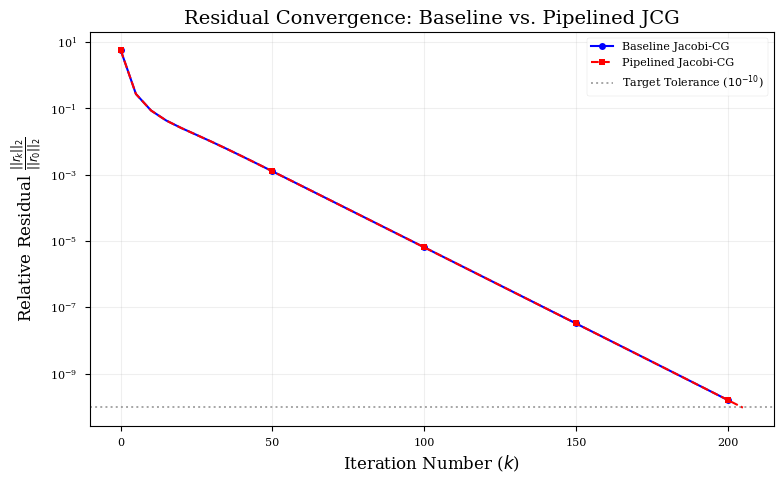

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_convergence_analysis(baseline_file: str = "../output/residual_baseline.txt",
                              pipelined_file: str = "../output/residual_pipelined.txt",
                              output_file_path: str = "../plots/convergence_analysis.eps") -> None:
    """
    Plot convergence analysis for the research report.
    Assumes files have columns: #iteration  residual_norm
    """
    
    # 1. Load Data (skiprows/comment handles the '#' in your C output)
    try:
        baseline_data = pd.read_csv(baseline_file, sep=r'\s+', comment='#', names=['iteration', 'residual'])
        pipelined_data = pd.read_csv(pipelined_file, sep=r'\s+', comment='#', names=['iteration', 'residual'])
    except FileNotFoundError as e:
        print(f"Error: Could not find result files. {e}")
        return

    # 2. Setup Plot Style
    plt.style.use('seaborn-v0_8-paper') # Or 'ggplot'
    plt.figure(figsize=(8, 5))

    # 3. Plot trajectories
    # We use markevery=10 so markers don't overlap too much
    plt.semilogy(baseline_data['iteration'], baseline_data['residual'], 
                 label='Baseline Jacobi-CG', 
                 color='blue', linestyle='-', marker='o', 
                 markevery=10, markersize=5, linewidth=1.5)

    plt.semilogy(pipelined_data['iteration'], pipelined_data['residual'], 
                 label='Pipelined Jacobi-CG', 
                 color='red', linestyle='--', marker='s', 
                 markevery=10, markersize=5, linewidth=1.5)

    # 4. Add Reference Tolerance Line (10^-10)
    plt.axhline(y=1e-10, color='gray', linestyle=':', alpha=0.7, label='Target Tolerance ($10^{-10}$)')

    # 5. Labels and Titles (Standard for academic papers)
    plt.title('Residual Convergence: Baseline vs. Pipelined JCG', fontsize=14)
    plt.xlabel('Iteration Number ($k$)', fontsize=12)
    plt.ylabel(r'Relative Residual $\frac{||r_k||_2}{||r_0||_2}$', fontsize=12)
    
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # 6. Save and clean up
    # Ensure plots directory exists
    os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
    
    plt.tight_layout()
    plt.savefig(output_file_path, format='eps', dpi=300)
    print(f"Plot saved to: {output_file_path}")
    plt.show()

plot_convergence_analysis()

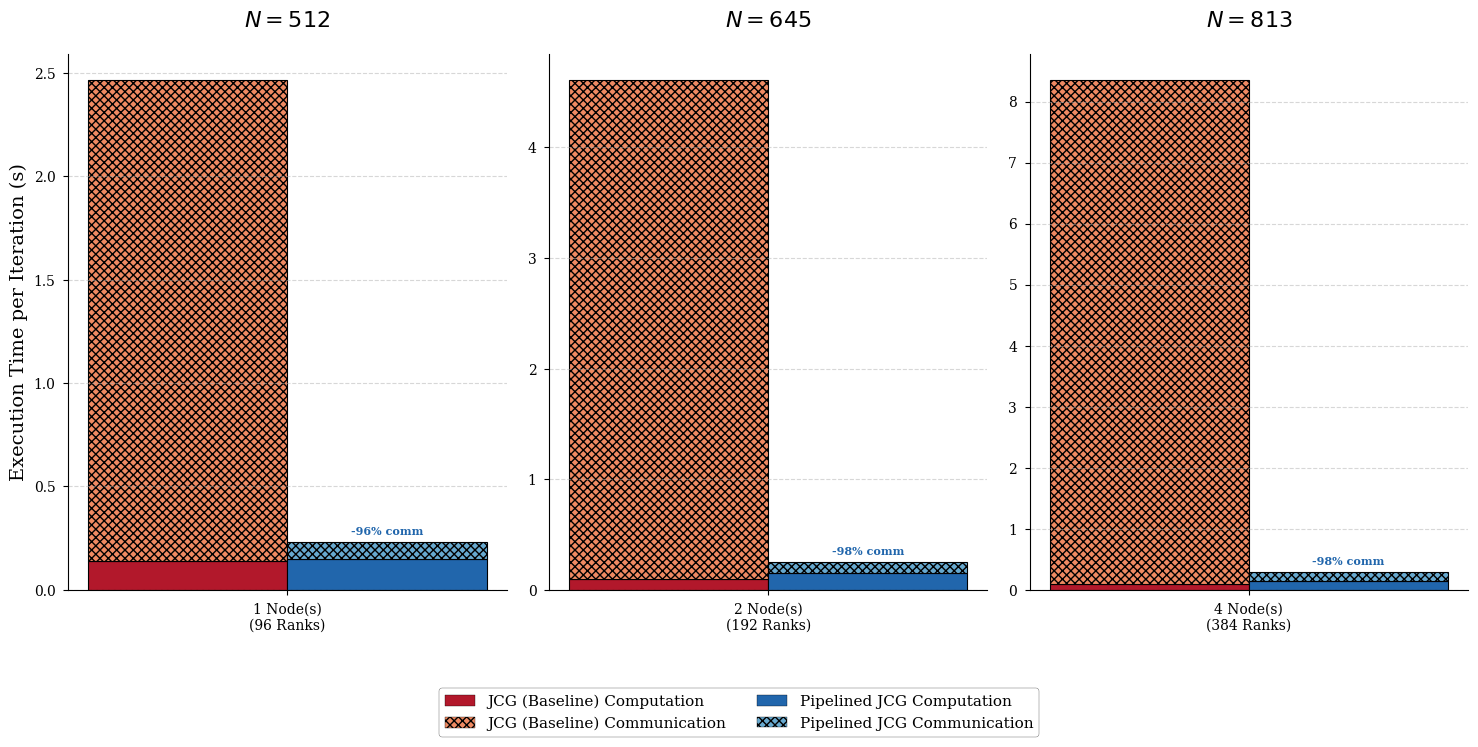

In [2]:
"""Communication vs. Computation Breakdown Plotter
This module provides a function to plot the breakdown of communication and computation times
for Baseline and Pipelined Jacobi Preconditioned Conjugate Gradient methods.
"""
plt.style.use('seaborn-v0_8-paper') # or 'bmh' if seaborn is not installed
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "savefig.dpi": 300
})

# High-Contrast Color Palette
COLORS = {
    'baseline': {
        'comp': '#b2182b',  # Deep Red
        'comm': '#ef8a62'   # Lighter Red/Orange
    },
    'pipelined': {
        'comp': '#2166ac',  # Deep Blue
        'comm': '#67a9cf'   # Lighter Blue
    }
}

def plot_comm_vs_comp_breakdown(file_path):
    df = pd.read_csv(file_path)
    
    # Average across repetitions
    df_clean = df.groupby(['algorithm', 'grid_size', 'num_processes']).min().reset_index()
    
    # # Segment calculation
    df_clean['computation_time'] = df_clean['avg_iter_time'] - df_clean['avg_comm_iter_time']
    df_clean['communication_time'] = df_clean['avg_comm_iter_time']
    
    grids = sorted(df_clean['grid_size'].unique())
    fig, axes = plt.subplots(1, len(grids), figsize=(15, 7), sharey=False)
    
    if len(grids) == 1: axes = [axes]

    for i, grid in enumerate(grids):
        ax = axes[i]
        subset = df_clean[df_clean['grid_size'] == grid].copy()
        
        ranks = sorted(subset['num_processes'].unique())
        x = np.arange(len(ranks))
        width = 0.4
        
        for alg in ['baseline', 'pipelined']:
            alg_data = subset[subset['algorithm'] == alg].sort_values('num_processes')
            if alg_data.empty: continue
            
            comp = alg_data['computation_time'].values
            comm = alg_data['communication_time'].values
            
            # Grouping offset
            pos = x - width/2 if alg == 'baseline' else x + width/2
            
            # --- PLOT COMPUTATION (Solid) ---
            ax.bar(pos, comp, width, 
                   color=COLORS[alg]['comp'], 
                   edgecolor='black', linewidth=0.8,
                   label=f'{alg.upper()} Computation')
            
            # --- PLOT COMMUNICATION (Hatched) ---
            # Using 'xxxx' for a very noticeable dense pattern
            ax.bar(pos, comm, width, bottom=comp, 
                   color=COLORS[alg]['comm'], 
                   hatch='xxxx', edgecolor='black', linewidth=0.8,
                   label=f'{alg.upper()} Communication')

        # Annotate Speedup on top of Pipelined bars
        # This adds extra "meaning" to the plot
        # for idx, r in enumerate(ranks):
        #     try:
        #         b_val = subset[(subset['algorithm'] == 'baseline') & (subset['num_processes'] == r)]['avg_iter_time'].values[0]
        #         p_val = subset[(subset['algorithm'] == 'pipelined') & (subset['num_processes'] == r)]['avg_iter_time'].values[0]
        #         speedup = b_val / p_val
        #         ax.text(idx + width/2, p_val + (max(subset['avg_iter_time'])*0.02), f'{speedup:.1f}x', 
        #                 ha='center', va='bottom', fontsize=9, color='#2166ac')
        #     except:
        #         pass

        for idx, r in enumerate(ranks):
            try:
                comm_base = subset[(subset['algorithm'] == 'baseline') & (subset['num_processes'] == r)]['communication_time'].values[0]
                comm_pipe = subset[(subset['algorithm'] == 'pipelined') & (subset['num_processes'] == r)]['communication_time'].values[0]
                reduction = (1 - comm_pipe / comm_base) * 100
                y_pos = subset[(subset['algorithm'] == 'pipelined') & (subset['num_processes'] == r)][['computation_time', 'communication_time']].sum(axis=1).values[0]
                ax.text(idx + width/2, y_pos + max(subset['avg_iter_time'])*0.01,
                        f'-{reduction:.0f}% comm', ha='center', va='bottom',
                        fontsize=8, color='#2166ac', fontweight='bold')
            except Exception:
                pass

        # Formatting
        ax.set_title(f'$N={int(grid)}$', fontsize=16, pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{int(r/96)} Node(s)\n({r} Ranks)' for r in ranks], fontsize=10)
        
        if i == 0:
            ax.set_ylabel('Execution Time per Iteration (s)', fontsize=14)
        
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        
        # Remove top/right spines for a cleaner look
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Custom Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=COLORS['baseline']['comp'], edgecolor='black', label='JCG (Baseline) Computation'),
        Patch(facecolor=COLORS['baseline']['comm'], edgecolor='black', hatch='xxxx', label='JCG (Baseline) Communication'),
        Patch(facecolor=COLORS['pipelined']['comp'], edgecolor='black', label='Pipelined JCG Computation'),
        Patch(facecolor=COLORS['pipelined']['comm'], edgecolor='black', hatch='xxxx', label='Pipelined JCG Communication')
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.08), 
               ncol=2, fontsize=11, frameon=True, facecolor='white', edgecolor='black')
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig("../plots/comm_vs_comp_breakdown.pdf", bbox_inches='tight')
    plt.show()

# Execution
file = "../output/jcgtimes_comm_times.txt"
plot_comm_vs_comp_breakdown(file_path=file)

In [3]:
df = pd.read_csv(file)
df_clean = df.groupby(['algorithm', 'grid_size', 'num_processes']).min().reset_index()
df_clean['computation_time'] = df_clean['avg_iter_time'] - df_clean['avg_comm_iter_time']
df_clean['communication_time'] = df_clean['avg_comm_iter_time']
df_clean[['algorithm', 'grid_size', 'num_processes', 'computation_time', 'communication_time']]

,algorithm,grid_size,num_processes,computation_time,communication_time
0,baseline,512,96,0.137070,2.330169
1,baseline,645,192,0.093585,4.517640
2,baseline,813,384,0.094108,8.260037
3,pipelined,512,96,0.149132,0.082993
4,pipelined,645,192,0.148943,0.105520
5,pipelined,813,384,0.146696,0.144764


In [4]:
df_clean[['algorithm', 'grid_size', 'num_processes', 'avg_iter_time', 'avg_comm_iter_time']]

,algorithm,grid_size,num_processes,avg_iter_time,avg_comm_iter_time
0,baseline,512,96,2.467239,2.330169
1,baseline,645,192,4.611225,4.517640
2,baseline,813,384,8.354145,8.260037
3,pipelined,512,96,0.232125,0.082993
4,pipelined,645,192,0.254463,0.105520
5,pipelined,813,384,0.291460,0.144764
